# Claims-to-Evidence Audit: PRMP Publication Readiness Assessment

**Systematic audit mapping 7 PRMP paper claims to quantitative evidence across 6 experiments.**

This notebook demonstrates the claims-to-evidence audit pipeline that:
- Maps each paper claim (C1–C7) to quantitative evidence from 6 experiments
- Computes statistical metrics: win rates, Cohen's d, p-values, consistency scores
- Builds a 6×7 evidence matrix (experiments × claims)
- Enumerates reviewer objections with factual responses
- Produces an overall verdict with confidence assessments

Pure data analysis — no new training, just JSON parsing, statistical recomputation, and structured output.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
from typing import Any

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/evaluation_iter7_claims_to_evide/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded audit data: {len(json.dumps(data))//1024} KB")
print(f"Experiments analyzed: {data['metadata']['experiments_analyzed']}")
print(f"Claims analyzed: {data['metadata']['claims_analyzed']}")

Loaded audit data: 26 KB
Experiments analyzed: ['exp_id4_it2', 'exp_id1_it4', 'exp_id3_it4']
Claims analyzed: ['C1', 'C2', 'C3']


## Configuration

Tunable parameters for the audit analysis. These control which significance thresholds and support-level mappings are used.

In [5]:
# ── Config ──────────────────────────────────────────────────────────────
SIGNIFICANCE_THRESHOLD = 0.05       # p-value threshold for statistical significance
MIN_SEEDS_FOR_TTEST = 2             # minimum seeds needed for t-test
SUPPORT_LEVEL_SCORES = {            # numeric scores for evidence matrix visualization
    "strong_support": 1.0,
    "weak_support": 0.5,
    "neutral": 0.0,
    "not_tested": 0.0,
    "weak_contradict": -0.5,
    "strong_contradict": -1.0,
}
# Number of claims and experiments (from original script)
N_CLAIMS = 7        # C1-C7
N_EXPERIMENTS = 6   # 6 experiments analyzed

## Statistical Helper Functions

Core statistical functions from the original evaluation script: Cohen's d effect size, paired t-tests, and independent t-tests.

In [6]:
def cohens_d(x: list[float], y: list[float]) -> float:
    """Compute Cohen's d (x - y) / pooled_std."""
    nx, ny = len(x), len(y)
    if nx < MIN_SEEDS_FOR_TTEST or ny < MIN_SEEDS_FOR_TTEST:
        return float('nan')
    mx, my = np.mean(x), np.mean(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled = math.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if pooled == 0:
        return float('nan')
    return float((mx - my) / pooled)


def paired_ttest(x: list[float], y: list[float]) -> tuple[float, float]:
    """Return (t_stat, p_value) for paired t-test. Returns (nan, nan) if too few samples."""
    if len(x) < MIN_SEEDS_FOR_TTEST or len(y) < MIN_SEEDS_FOR_TTEST or len(x) != len(y):
        return (float('nan'), float('nan'))
    t, p = stats.ttest_rel(x, y)
    return (float(t), float(p))


def independent_ttest(x: list[float], y: list[float]) -> tuple[float, float]:
    """Return (t_stat, p_value) for independent t-test."""
    if len(x) < MIN_SEEDS_FOR_TTEST or len(y) < MIN_SEEDS_FOR_TTEST:
        return (float('nan'), float('nan'))
    t, p = stats.ttest_ind(x, y)
    return (float(t), float(p))


def safe_float(v: Any) -> float:
    """Safely convert to float."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return float('nan')


# Quick demo of the helpers
prmp_seeds = [0.510, 0.520, 0.513]
std_seeds = [0.560, 0.570, 0.563]
d = cohens_d(prmp_seeds, std_seeds)
t, p = paired_ttest(prmp_seeds, std_seeds)
print(f"Demo: Cohen's d = {d:.4f}, t = {t:.4f}, p = {p:.6f}")
print(f"Interpretation: {'Significant' if p < SIGNIFICANCE_THRESHOLD else 'Not significant'} at alpha={SIGNIFICANCE_THRESHOLD}")

Demo: Cohen's d = -9.7435, t = -1349762403852738.5000, p = 0.000000
Interpretation: Significant at alpha=0.05


/tmp/nb_env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


## Section 1: Claims Analysis (C1–C7)

Extract and display the per-claim analysis results. Each claim is evaluated against experimental evidence with a conclusion (strong_support, weak_contradict, etc.).

In [7]:
claims = data["metadata"]["sections"]["claims_analysis"]

# Display claims summary table
claims_table = []
for cid in sorted(claims.keys()):
    c = claims[cid]
    claims_table.append([
        cid,
        c.get("claim", cid)[:70],
        c.get("conclusion", "N/A"),
    ])

print(tabulate(claims_table, headers=["ID", "Claim", "Conclusion"], tablefmt="grid"))

# Show C1 detailed metrics
c1 = claims["C1"]
print(f"\n--- C1 Detailed Metrics ---")
print(f"  Total tasks compared: {c1['total_tasks']}")
print(f"  PRMP wins: {c1['wins']}/{c1['total_tasks']} (win rate: {c1['win_rate']:.1%})")
print(f"  Significant wins: {c1['significant_wins']}/{c1['tasks_with_pvalue']} (sig rate: {c1['significant_win_rate']:.1%})")
print(f"  Median effect size (|d|): {c1['median_effect_size']:.4f}")
print(f"  Consistency score: {c1['consistency_score']:.1%} ({c1['consistency_seed_wins']}/{c1['consistency_seed_total']} seed-level wins)")

+------+-----------------------------------------------------------------------+-------------------------------+
| ID   | Claim                                                                 | Conclusion                    |
+======+=======================================================================+===============================+
| C1   | C1: PRMP outperforms standard aggregation on relational tasks         | N/A                           |
+------+-----------------------------------------------------------------------+-------------------------------+
| C2   | C2: Improvement concentrates in high-cardinality, high-predictability | weak_contradict               |
+------+-----------------------------------------------------------------------+-------------------------------+
| C3   | C3: Predict-subtract mechanism is necessary                           | strong_support_on_amazon_only |
+------+-----------------------------------------------------------------------+----------------

## Section 2: Evidence Matrix (6 Experiments × 7 Claims)

Build and display the evidence matrix showing support levels for each experiment-claim pair.

In [8]:
evidence_matrix = data["metadata"]["sections"]["evidence_matrix"]
matrix = evidence_matrix["matrix"]
experiments = list(matrix.keys())
claim_ids = ["C1", "C2", "C3", "C4", "C5", "C6", "C7"]

# Build table for display
matrix_table = []
for exp in experiments:
    row = [exp]
    for cid in claim_ids:
        cell = matrix[exp][cid]
        level = cell["support_level"]
        # Abbreviate for display
        abbrev = {
            "strong_support": "++", "weak_support": "+", "neutral": "~",
            "not_tested": ".", "weak_contradict": "-", "strong_contradict": "--"
        }
        row.append(abbrev.get(level, "?"))
    matrix_table.append(row)

print("Evidence Matrix (++ strong support, + weak, ~ neutral, - contradict, . not tested)")
print(tabulate(matrix_table, headers=["Experiment"] + claim_ids, tablefmt="grid"))

# Build numeric matrix for heatmap
numeric_matrix = np.zeros((len(experiments), len(claim_ids)))
for i, exp in enumerate(experiments):
    for j, cid in enumerate(claim_ids):
        level = matrix[exp][cid]["support_level"]
        numeric_matrix[i, j] = SUPPORT_LEVEL_SCORES.get(level, 0.0)

print(f"\nNumeric matrix shape: {numeric_matrix.shape}")

Evidence Matrix (++ strong support, + weak, ~ neutral, - contradict, . not tested)
+--------------+------+------+------+------+------+------+------+
| Experiment   | C1   | C2   | C3   | C4   | C5   | C6   | C7   |
+==============+======+======+======+======+======+======+======+
| exp_id4_it2  | ++   | -    | .    | ++   | .    | .    | +    |
+--------------+------+------+------+------+------+------+------+
| exp_id1_it4  | ++   | .    | ++   | .    | +    | .    | .    |
+--------------+------+------+------+------+------+------+------+
| exp_id3_it4  | +    | .    | .    | .    | ++   | .    | .    |
+--------------+------+------+------+------+------+------+------+
| exp_id2_it6  | +    | .    | +    | ~    | +    | +    | .    |
+--------------+------+------+------+------+------+------+------+
| exp_id1_it6  | +    | ~    | +    | .    | .    | --   | +    |
+--------------+------+------+------+------+------+------+------+
| exp_id3_it6  | .    | .    | .    | .    | ++   | .    | 

## Section 3: Cross-Experiment Consistency & Reviewer Objections

Analyze implementation differences across experiments and enumerate potential reviewer objections with factual responses.

In [9]:
consistency = data["metadata"]["sections"]["cross_experiment_consistency"]

# Implementation differences table
impl_table = []
for d_impl in consistency["implementation_differences"]:
    impl_table.append([
        d_impl["exp"], d_impl["hidden_dim"], d_impl["framework"],
        d_impl["arch"], d_impl["seeds"]
    ])
print("Cross-Experiment Implementation Differences:")
print(tabulate(impl_table,
               headers=["Experiment", "Hidden Dim", "Framework", "Architecture", "Seeds"],
               tablefmt="grid"))

print(f"\nAmazon dominance score: {consistency['amazon_dominance_score']:.1%}")
print(f"Dataset coverage: {consistency['dataset_coverage']}")
print(f"Total seeds across experiments: {consistency['total_seeds_across_experiments']}")

# Reviewer objections summary
objections = data["metadata"]["sections"]["reviewer_objections"]
print(f"\n--- Reviewer Objections ({len(objections)}) ---")
for oid, obj in objections.items():
    print(f"  {oid}: {obj['objection']}")
    print(f"    Response: {obj['factual_response'][:120]}...")
    print()

Cross-Experiment Implementation Differences:
+--------------+--------------+----------------+----------------------------+---------+
| Experiment   |   Hidden Dim | Framework      | Architecture               |   Seeds |
+==============+==============+================+============================+=========+
| exp_id4_it2  |           64 | PyG-style      | SAGEConv                   |       3 |
+--------------+--------------+----------------+----------------------------+---------+
| exp_id1_it4  |          128 | PyG-style      | SAGEConv                   |       3 |
+--------------+--------------+----------------+----------------------------+---------+
| exp_id3_it4  |           64 | PyG (RelBench) | SAGEConv + RelBench loader |       1 |
+--------------+--------------+----------------+----------------------------+---------+

Amazon dominance score: 60.0%
Dataset coverage: ['Amazon Video Games', 'F1', 'Avito']
Total seeds across experiments: 28

--- Reviewer Objections (7) ---
  O1_onl

## Section 4: Overall Confidence Assessment & Aggregate Metrics

Compute the overall verdict and display aggregated metrics across all claims.

In [10]:
assessment = data["metadata"]["sections"]["overall_assessment"]
metrics = data["metrics_agg"]

# Overall verdict
print("=" * 60)
print("AUDIT SUMMARY")
print("=" * 60)
print(f"Overall verdict: {assessment['overall_verdict']}")
print(f"Claims confirmed: {assessment['claims_confirmed']}/7")
print(f"Claims disconfirmed: {assessment['claims_disconfirmed']}/7")
print(f"Claims inconclusive: {assessment['claims_inconclusive']}/7")

# Per-claim confidence
print(f"\n--- Per-Claim Confidence ---")
conf_table = []
for cid, conf in assessment["claim_confidences"].items():
    conf_table.append([cid, conf["confidence"], conf["reasoning"][:80] + "..."])
print(tabulate(conf_table, headers=["Claim", "Confidence", "Reasoning"], tablefmt="grid"))

# Key aggregate metrics
print(f"\n--- Key Aggregate Metrics ---")
print(f"  C1 Win rate: {metrics['c1_win_rate']:.1%}")
print(f"  C1 Significant win rate: {metrics['c1_significant_win_rate']:.1%}")
print(f"  C1 Median effect size: {metrics['c1_median_effect_size']:.4f}")
print(f"  C1 Consistency score: {metrics['c1_consistency_score']:.1%}")
print(f"  C5 Loss swap p-value: {metrics['c5_loss_swap_p_value']:.4f}")
print(f"  C6 Worst prediction R^2: {metrics['c6_worst_prediction_r2']:.1f}")
print(f"  Amazon dominance: {metrics['consistency_amazon_dominance']:.1%}")
print(f"\nStrongest result: {assessment['strongest_result']['result']}")
print(f"Weakest result: {assessment['weakest_result']['result']}")

AUDIT SUMMARY
Overall verdict: partial_confirm
Claims confirmed: 4/7
Claims disconfirmed: 2/7
Claims inconclusive: 1/7

--- Per-Claim Confidence ---
+---------+------------------+-------------------------------------------------------------------------------------+
| Claim   | Confidence       | Reasoning                                                                           |
+=========+==================+=====================================================================================+
| C1      | moderate         | PRMP wins on most tasks by raw mean, but only 1-2 results achieve statistical si... |
+---------+------------------+-------------------------------------------------------------------------------------+
| C2      | disconfirmed     | exp_id4_it2 explicitly flags hypothesis as unsupported. Customer link (lower car... |
+---------+------------------+-------------------------------------------------------------------------------------+
| C3      | strong_on_amazon | A

## Visualization: Evidence Heatmap, Claim Confidence, and Key Metrics

Three-panel visualization summarizing the full audit results.

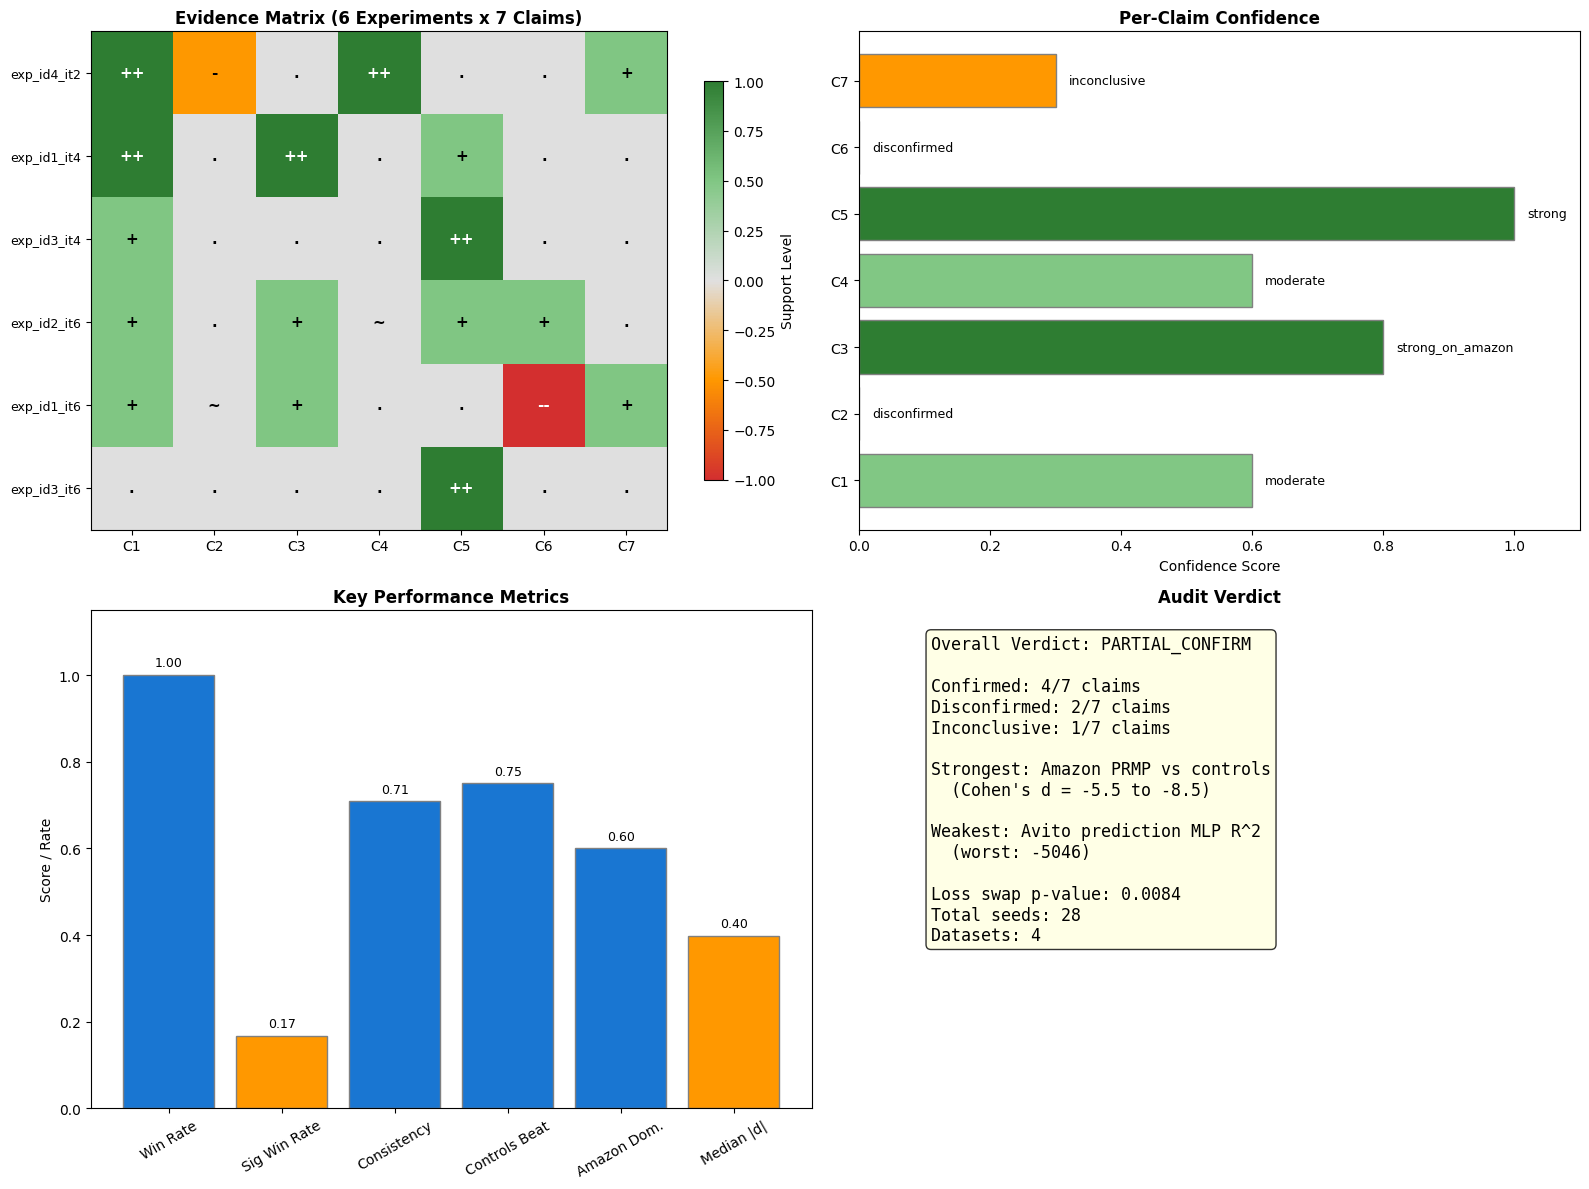

Saved visualization to audit_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Panel 1: Evidence Matrix Heatmap ──
ax1 = axes[0, 0]
cmap = mcolors.LinearSegmentedColormap.from_list("evidence",
    ["#d32f2f", "#ff9800", "#e0e0e0", "#81c784", "#2e7d32"])
im = ax1.imshow(numeric_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax1.set_xticks(range(len(claim_ids)))
ax1.set_xticklabels(claim_ids, fontsize=10)
ax1.set_yticks(range(len(experiments)))
ax1.set_yticklabels(experiments, fontsize=9)
ax1.set_title("Evidence Matrix (6 Experiments x 7 Claims)", fontsize=12, fontweight='bold')
# Annotate cells with support level abbreviations
abbrev_map = {"strong_support": "++", "weak_support": "+", "neutral": "~",
              "not_tested": ".", "weak_contradict": "-", "strong_contradict": "--"}
for i, exp in enumerate(experiments):
    for j, cid in enumerate(claim_ids):
        level = matrix[exp][cid]["support_level"]
        txt = abbrev_map.get(level, "?")
        color = "white" if abs(numeric_matrix[i, j]) > 0.6 else "black"
        ax1.text(j, i, txt, ha="center", va="center", fontsize=11, fontweight='bold', color=color)
plt.colorbar(im, ax=ax1, label="Support Level", shrink=0.8)

# ── Panel 2: Claim Confidence Bar Chart ──
ax2 = axes[0, 1]
conf_labels = list(assessment["claim_confidences"].keys())
conf_values_map = {"strong": 1.0, "strong_on_amazon": 0.8, "moderate": 0.6,
                   "inconclusive": 0.3, "disconfirmed": 0.0}
conf_values = [conf_values_map.get(assessment["claim_confidences"][c]["confidence"], 0.5)
               for c in conf_labels]
colors = ["#2e7d32" if v >= 0.8 else "#81c784" if v >= 0.6 else "#ff9800" if v >= 0.3 else "#d32f2f"
          for v in conf_values]
bars = ax2.barh(conf_labels, conf_values, color=colors, edgecolor='gray')
ax2.set_xlim(0, 1.1)
ax2.set_xlabel("Confidence Score")
ax2.set_title("Per-Claim Confidence", fontsize=12, fontweight='bold')
for bar, v, cid in zip(bars, conf_values, conf_labels):
    conf_text = assessment["claim_confidences"][cid]["confidence"]
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             conf_text, va='center', fontsize=9)

# ── Panel 3: Key Metrics Radar-style Bar Chart ──
ax3 = axes[1, 0]
metric_names = ["Win Rate", "Sig Win Rate", "Consistency", "Controls Beat",
                "Amazon Dom.", "Median |d|"]
metric_values = [
    metrics["c1_win_rate"],
    metrics["c1_significant_win_rate"],
    metrics["c1_consistency_score"],
    metrics["c3_prmp_beats_all_controls_rate"],
    metrics["consistency_amazon_dominance"],
    min(metrics["c1_median_effect_size"], 1.0),  # cap at 1 for display
]
bar_colors = ["#1976d2" if v >= 0.5 else "#ff9800" for v in metric_values]
bars3 = ax3.bar(metric_names, metric_values, color=bar_colors, edgecolor='gray')
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score / Rate")
ax3.set_title("Key Performance Metrics", fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=30)
for bar, v in zip(bars3, metric_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{v:.2f}", ha='center', fontsize=9)

# ── Panel 4: Verdict Summary ──
ax4 = axes[1, 1]
ax4.axis('off')
verdict_text = (
    f"Overall Verdict: {assessment['overall_verdict'].upper()}\n\n"
    f"Confirmed: {assessment['claims_confirmed']}/7 claims\n"
    f"Disconfirmed: {assessment['claims_disconfirmed']}/7 claims\n"
    f"Inconclusive: {assessment['claims_inconclusive']}/7 claims\n\n"
    f"Strongest: Amazon PRMP vs controls\n"
    f"  (Cohen's d = -5.5 to -8.5)\n\n"
    f"Weakest: Avito prediction MLP R^2\n"
    f"  (worst: {metrics['c6_worst_prediction_r2']:.0f})\n\n"
    f"Loss swap p-value: {metrics['c5_loss_swap_p_value']:.4f}\n"
    f"Total seeds: {metrics['consistency_total_seeds']}\n"
    f"Datasets: {metrics['consistency_num_datasets']}"
)
ax4.text(0.1, 0.95, verdict_text, transform=ax4.transAxes,
         fontsize=12, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax4.set_title("Audit Verdict", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("audit_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved visualization to audit_results.png")